## Calculation of variance of random component by variate difference method. 

--- Dynamic Variate Difference Method ---


Enter the order of difference (e.g., 1 for 1st-order, 2 for 2nd-order):  1


Fetching 'dowjones' dataset from Seaborn...

--- RESULTS ---
Order of Difference (k): 1
Combinatorial Constant Divided By: 2
Mean of Differences: 1.4049
Variance of Differences: 155.6088
Variance of Random Components: 77.8044
-----------------



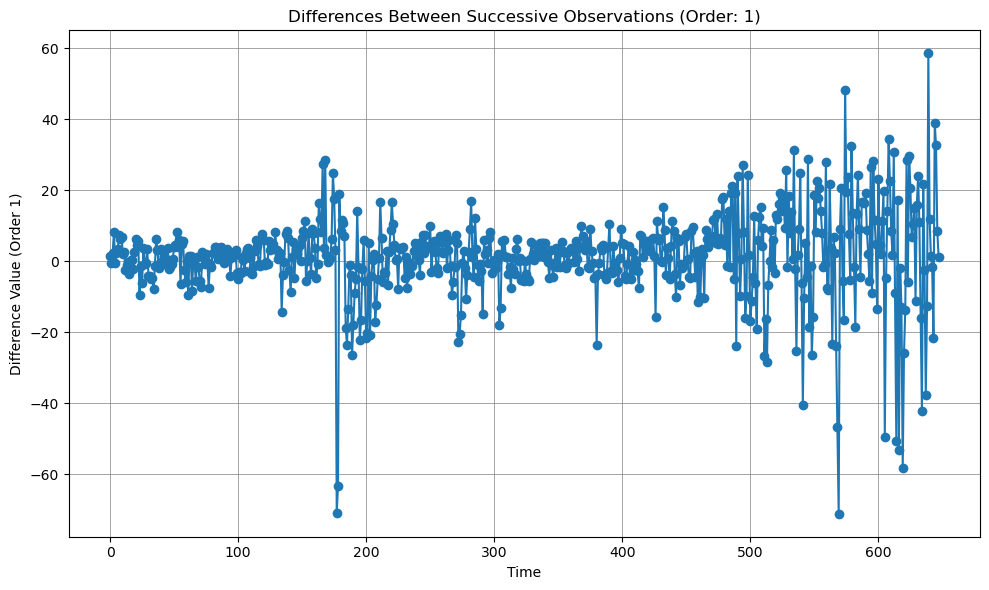

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math  # Needed to calculate the combination formula automatically

def dynamic_variate_difference():
    """
    Dynamic Variate Difference Method.
    Allows the user to input the desired order of difference (k).
    """
    print("--- Dynamic Variate Difference Method ---")
    
    # Input the desired order of difference
    try:
        k = int(input("Enter the order of difference (e.g., 1 for 1st-order, 2 for 2nd-order): "))
        if k < 1:
            print("Please enter a positive integer of 1 or higher.")
            return
    except ValueError:
        print("Invalid input. Please enter a natural number.")
        return

    # 1. Load and prep the data
    print("Fetching 'dowjones' dataset from Seaborn...")
    df = sns.load_dataset('dowjones')
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values(by='Date', ascending=True)
    price_array = df['Price'].to_numpy()

    # 2. Dynamic Differencing
    # The 'n=k' parameter tells NumPy exactly how many times to difference the data
    differences = np.diff(price_array, n=k)
    
    # 3. Calculate statistical metrics
    mean_diff = np.mean(differences)
    var_diff = np.var(differences)
    
    # 4. Dynamic Combinatorial Constant Calculation
    # Formula is (2k)! / (k!k!). Python's math.comb(2k, k) does this instantly.
    combinatorial_constant = math.comb(2 * k, k)
    
    var_random = var_diff / combinatorial_constant
    
    # 5. Print dynamic results
    print("\n--- RESULTS ---")
    print(f"Order of Difference (k): {k}")
    print(f"Combinatorial Constant Divided By: {combinatorial_constant}")
    print(f"Mean of Differences: {mean_diff:.4f}")
    print(f"Variance of Differences: {var_diff:.4f}")
    print(f"Variance of Random Components: {var_random:.4f}")
    print("-----------------\n")

    # 6. Plot the results
    plt.figure(figsize=(10, 6))
    time_index = np.arange(len(differences))
    plt.plot(time_index, differences, marker='o', linestyle='-', color='tab:blue')
    
    plt.title(f"Differences Between Successive Observations (Order: {k})")
    plt.xlabel("Time")
    plt.ylabel(f"Difference Value (Order {k})")
    plt.grid(True, linestyle='-', linewidth=0.5, color='gray')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    dynamic_variate_difference()

# VIVA Q&A on above 
## <i> What is Variate Difference Method (VDM) ?
## It is a statistical technique  where  we continuously subtract consecutive data points from one another. It isolates the noise from the time series data by removing the long term upward/downward trend.
## <i> What is random component ?
## It is the unpredictable messy part of time-series data which has random short time peaks and troughs.
## <i> What are VDM applicaitons ?
## We use this to clean up time series data (like daily stock prices) by separating the real trends from the random noise, we can make much more accurate future predictions.